In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 3000 files belonging to 2 classes.
['fake', 'real']


In [3]:
## Loading the model
model = tf.keras.models.load_model('Trained_model.keras')

c:\Users\Gopal Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


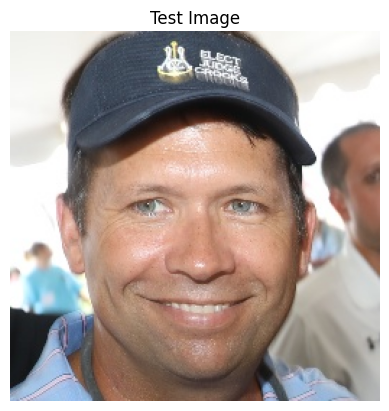

In [6]:
# Visualizing and performing prediction on single image


#Test Image Visualization
import cv2
import matplotlib.pyplot as plt
import os

image_path = r'C:\Users\Gopal Sharma\OneDrive\Desktop\project 2\Fake Face Detection\valid\real\00011.jpg'

if not os.path.exists(image_path):
    print("Image path not found:", image_path)
else:
    img = cv2.imread(image_path)
    if img is None:
        print("Failed to load image. Check path or file format.")
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title('Test Image')
        plt.axis('off')
        plt.show()


In [7]:
#Test Image Prediction
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = model.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step


In [8]:
print(predictions)

[[0. 1.]]


In [9]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

1


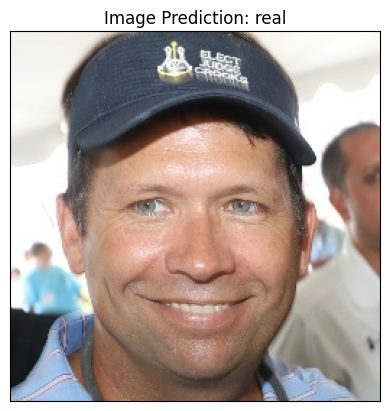

Confidence: 100.00%


In [10]:
# Displaying the image with predicted label
model_prediction = class_name[result_index]
confidence = predictions[0][result_index] * 100  # convert to %
plt.imshow(img)
plt.title(f"Image Prediction: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


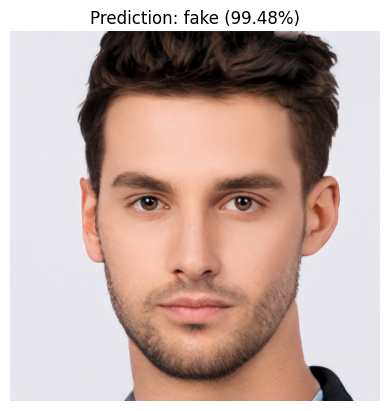

Confidence: 99.48%


In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r"C:\Users\Gopal Sharma\OneDrive\Desktop\project 2\Fake Face Detection\100k-ai-faces-6.jpg"

# Load and check
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

# Convert + resize + normalize
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128,128))
input_arr = np.expand_dims(img_resized, axis=0) / 255.0

# Predict
predictions = model.predict(input_arr)
class_name = ['fake', 'real']
result_index = np.argmax(predictions)
confidence = predictions[0][result_index] * 100

# Display
plt.imshow(img_rgb)
plt.title(f"Prediction: {class_name[result_index]} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Confidence: {confidence:.2f}%")


In [19]:
for images, labels in validation_set.take(1):  # take one batch
    predictions = model.predict(images)
    for i in range(len(images)):
        pred_index = np.argmax(predictions[i])
        true_index = np.argmax(labels[i])
        print(f"True: {class_name[true_index]}, Predicted: {class_name[pred_index]}, Confidence: {predictions[i][pred_index]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
True: real, Predicted: fake, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: fake, Predicted: real, Confidence: 100.00%
True: fake, Predicted: real, Confidence: 99.94%
True: fake, Predicted: fake, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: fake, Predicted: real, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: fake, Predicted: fake, Confidence: 100.00%
True: real, Predicted: real, Confidence: 100.00%
True: real, Predicted: fake, Co

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


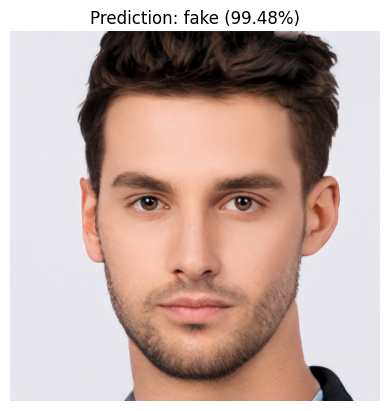

Confidence: 99.48%


In [23]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt

detector = MTCNN()

# Test image path
img_path = r"C:\Users\Gopal Sharma\OneDrive\Desktop\project 2\Fake Face Detection\100k-ai-faces-6.jpg"

img = cv2.imread(img_path)
faces = detector.detect_faces(img_path)

if len(faces) == 0:
    print("No human face detected! Please upload a human face image.")
else:
    # proceed to CNN model prediction
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Convert + resize + normalize
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128,128))
    input_arr = np.expand_dims(img_resized, axis=0) / 255.0

    # Predict
    predictions = model.predict(input_arr)
    class_name = ['fake', 'real']
    result_index = np.argmax(predictions)
    confidence = predictions[0][result_index] * 100

    # Display
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {class_name[result_index]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Confidence: {confidence:.2f}%")



In [24]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt

detector = MTCNN()

# Test image path
img_path = r"C:\Users\Gopal Sharma\OneDrive\Desktop\project 2\Fake Face Detection\Dog.jpg"

img = cv2.imread(img_path)
faces = detector.detect_faces(img_path)

if len(faces) == 0:
    print("No human face detected! Please upload a human face image.")
else:
    # proceed to CNN model prediction
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Convert + resize + normalize
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128,128))
    input_arr = np.expand_dims(img_resized, axis=0) / 255.0

    # Predict
    predictions = model.predict(input_arr)
    class_name = ['fake', 'real']
    result_index = np.argmax(predictions)
    confidence = predictions[0][result_index] * 100

    # Display
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {class_name[result_index]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Confidence: {confidence:.2f}%")



No human face detected! Please upload a human face image.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


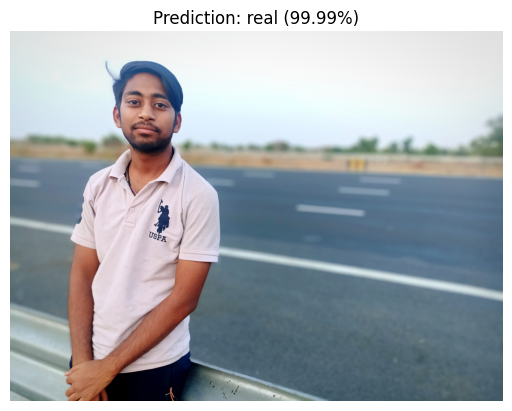

Confidence: 99.99%


In [27]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt

detector = MTCNN()

# Test image path
img_path = r"1.jpg"

img = cv2.imread(img_path)
faces = detector.detect_faces(img_path)

if len(faces) == 0:
    print("No human face detected! Please upload a human face image.")
else:
    # proceed to CNN model prediction
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Convert + resize + normalize
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128,128))
    input_arr = np.expand_dims(img_resized, axis=0) / 255.0

    # Predict
    predictions = model.predict(input_arr)
    class_name = ['fake', 'real']
    result_index = np.argmax(predictions)
    confidence = predictions[0][result_index] * 100

    # Display
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {class_name[result_index]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Confidence: {confidence:.2f}%")



In [1]:
from mtcnn import MTCNN
import cv2
import numpy as np
import matplotlib.pyplot as plt

detector = MTCNN()

# Test image path
img_path = r"11.jpg"

img = cv2.imread(img_path)
faces = detector.detect_faces(img_path)

if len(faces) == 0:
    print("No human face detected! Please upload a human face image.")
else:
    # proceed to CNN model prediction
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Convert + resize + normalize
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128,128))
    input_arr = np.expand_dims(img_resized, axis=0) / 255.0

    # Predict
    predictions = model.predict(input_arr)
    class_name = ['fake', 'real']
    result_index = np.argmax(predictions)
    confidence = predictions[0][result_index] * 100

    # Display
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {class_name[result_index]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Confidence: {confidence:.2f}%")



No human face detected! Please upload a human face image.
